# Credit Risk Prediction: A Machine Learning Approach

## Introduction

This notebook aims to develop a machine learning model to predict credit risk using a given dataset. Credit risk prediction is a crucial task for financial institutions to assess the likelihood of a borrower defaulting on a loan. By accurately predicting credit risk, institutions can make informed decisions regarding loan approvals, interest rates, and overall risk management, thereby minimizing potential financial losses and ensuring sustainable growth.

This analysis will cover data loading, preprocessing, exploratory data analysis (EDA), model training, evaluation, and feature importance analysis. We will leverage various Python libraries such as pandas for data manipulation, scikit-learn for machine learning, and matplotlib/seaborn for visualizations.

## About the Dataset

The dataset used in this analysis contains various features related to loan applicants and their loan details. Key features include:

*   **person_age**: Age of the loan applicant.
*   **person_income**: Annual income of the loan applicant.
*   **person_home_ownership**: Type of home ownership (e.g., RENT, OWN, MORTGAGE, OTHER).
*   **person_emp_length**: Employment length in years.
*   **loan_intent**: Purpose of the loan (e.g., EDUCATION, MEDICAL, VENTURE, PERSONAL, HOMEIMPROVEMENT).
*   **loan_grade**: Loan grade assigned by the lending institution (A-G).
*   **loan_amnt**: Loan amount requested.
*   **loan_int_rate**: Interest rate of the loan.
*   **loan_status**: Target variable; 0 for non-default, 1 for default.
*   **loan_percent_income**: Loan amount as a percentage of person's income.
*   **cb_person_default_on_file**: Whether the person has a default on their credit file (Y/N).
*   **cb_person_cred_hist_length**: Length of the person's credit history in years.

The dataset is crucial for building a predictive model that can identify patterns associated with loan defaults.

## Problem Statement

The primary objective of this project is to build a robust machine learning model capable of predicting loan default (`loan_status`). The model should be able to assist financial institutions in making more accurate lending decisions by identifying high-risk applicants. A key aspect of this problem is balancing the prediction of true positives (correctly identifying defaulters) with minimizing false positives (incorrectly identifying non-defaulters as defaulters), which can lead to lost business opportunities. We will evaluate the model's performance using metrics such as precision, recall, F1-score, and accuracy, with a particular focus on optimizing for recall for the positive class (default) to ensure that most potential defaulters are identified.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Unzip the credit_risk_dataset.csv.zip file
!unzip /content/credit_risk_dataset.csv.zip

Archive:  /content/credit_risk_dataset.csv.zip
  inflating: credit_risk_dataset.csv  


In [ ]:
# Read the extracted CSV file into a pandas DataFrame
df = pd.read_csv('credit_risk_dataset.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Explanation: Data Loading and Initial Inspection

After unzipping the compressed file, the `credit_risk_dataset.csv` was loaded into a pandas DataFrame. The `display(df.head())` command was used to show the first five rows, providing an initial glimpse into the data structure, column names, and data types. This step is essential to confirm that the data has been loaded correctly and to begin understanding its format.

In [ ]:
df.shape

(32581, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


### Explanation: Data Preprocessing (One-Hot Encoding & KNN Imputation)

Before training a machine learning model, data preprocessing is vital. Here, we performed several key steps:

1.  **Separating Target Variable**: The `loan_status` column was separated from the features (`X_raw`) to prevent its alteration during preprocessing, as it is our target variable.
2.  **One-Hot Encoding**: Categorical features like `person_home_ownership`, `loan_intent`, `loan_grade`, and `cb_person_default_on_file` were converted into numerical format using one-hot encoding. `pd.get_dummies` was used with `drop_first=True` to avoid multicollinearity. This is necessary because many machine learning algorithms, especially KNN, require numerical input.
3.  **KNN Imputation**: Missing values in `person_emp_length` and `loan_int_rate` (as seen from `df.info()`) were handled using `KNNImputer`. This method imputes missing values based on the values of the 5 nearest neighbors in the feature space. This approach is generally more robust than simple mean/median imputation as it considers the local structure of the data, especially when categorical features have been converted to numerical format.

In [ ]:
# 2. Separate target array before hot-encoding to protect it from alteration
y = df['loan_status']
X_raw = df.drop(columns=['loan_status'])

# 3. One-Hot Encode categorical metrics (KNN requires numerical coordinates to compute distances)
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
X_encoded = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True, dtype=int)

print("Executing 5-Nearest Neighbors spatial imputation mapping...")
# 4. Initialize the KNN Imputer (calculates missing cells using the 5 closest structural rows)
imputer = KNNImputer(n_neighbors=5)
X_imputed_array = imputer.fit_transform(X_encoded)

# 5. Cast back into a clean, structured pandas Dataframe
X_features = pd.DataFrame(X_imputed_array, columns=X_encoded.columns)

print(f"KNN Imputation complete! Retained total sample count: {X_features.shape[0]} (Zero profiles dropped!)")

Executing 5-Nearest Neighbors spatial imputation mapping...
KNN Imputation complete! Retained total sample count: 32581 (Zero profiles dropped!)


In [ ]:
# 1. Add intercept constant for proper Statsmodels execution
X_stats_const = sm.add_constant(X_features)

# 2. Fit an OLS Linear Probability Model to examine feature p-values
ols_reg = sm.OLS(y, X_stats_const).fit()
print("==============================================================================")
print("                                 OLS REGRESSION SUMMARY                       ")
print("==============================================================================")
print(ols_reg.summary().tables[1])

# 3. Compute Variance Inflation Factor (VIF) to detect feature redundancies
vif_df = pd.DataFrame()
vif_df["Risk_Feature"] = X_features.columns
vif_df["VIF_Value"] = [variance_inflation_factor(X_features.values, i) for i in range(X_features.shape[1])]

print("\n==============================================================================")
print("                        VARIANCE INFLATION FACTOR (VIF)                       ")
print("==============================================================================")
print(vif_df.round(2).sort_values(by="VIF_Value", ascending=False).to_string(index=False))

                                 OLS REGRESSION SUMMARY                       
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -0.0773      0.017     -4.591      0.000      -0.110      -0.044
person_age                     -0.0010      0.001     -1.702      0.089      -0.002       0.000
person_income                3.344e-07   3.65e-08      9.165      0.000    2.63e-07    4.06e-07
person_emp_length              -0.0005      0.000     -0.991      0.322      -0.001       0.000
loan_amnt                    -1.44e-05   4.33e-07    -33.229      0.000   -1.52e-05   -1.35e-05
loan_int_rate                   0.0071      0.001      5.279      0.000       0.004       0.010
loan_percent_income             1.8001      0.025     71.288      0.000       1.751       1.850
cb_person_cred_hist_length      0.0009      0.001      1.

### Explanation: OLS Regression and VIF Analysis

1.  **OLS Regression**: An Ordinary Least Squares (OLS) Linear Probability Model was fitted to the data. This provides statistical insights into the relationship between each feature and the target variable (`loan_status`). The p-values from the OLS summary help identify features that are statistically significant predictors of loan default. Features with high p-values (e.g., `person_age`, `person_emp_length`, `loan_intent_HOMEIMPROVEMENT`, `cb_person_default_on_file_Y`) might be less influential in predicting loan default.
2.  **Variance Inflation Factor (VIF)**: VIF was calculated for each feature to detect multicollinearity. High VIF values (typically > 5 or 10) indicate that a feature can be largely explained by other features in the model, suggesting redundancy and potential instability in coefficient estimates. Features like `loan_int_rate` and `person_age` show high VIF values, indicating a strong correlation with other predictors. While not always directly addressed for tree-based models like Random Forest, understanding multicollinearity is important for model interpretation and for other linear models.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Initialize the Random Forest architecture
rf_cv = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)

# 2. Establish a Stratified 5-Fold cross-validation strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Evaluating Random Forest stability across 5 Stratified Folds...")
# 3. Compute cross-validated Accuracy metrics
cv_scores = cross_val_score(rf_cv, X_features, y, cv=cv_strategy, scoring='accuracy', n_jobs=-1)

print("\n==============================================================================")
print("                    CROSS-VALIDATION STABILITY REPORT                         ")
print("==============================================================================")
print(f"Individual Fold Accuracies: {cv_scores}")
print(f"Mean Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f} variance)")

# 4. Fit on the final stratified holdout set to generate the crisp test logs
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.2, stratify=y, random_state=42)
rf_cv.fit(X_train, y_train)
y_pred_rf = rf_cv.predict(X_test)

print("\n==============================================================================")
print("                    FINAL TESTING HOLDOUT PERFORMANCE                         ")
print("==============================================================================")
print(classification_report(y_test, y_pred_rf))

Evaluating Random Forest stability across 5 Stratified Folds...

                    CROSS-VALIDATION STABILITY REPORT                         
Individual Fold Accuracies: [0.91790701 0.92311234 0.92372621 0.91589932 0.92034991]
Mean Cross-Validation Accuracy: 0.9202 (+/- 0.0060 variance)

                    FINAL TESTING HOLDOUT PERFORMANCE                         
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      5095
           1       0.96      0.67      0.79      1422

    accuracy                           0.92      6517
   macro avg       0.94      0.83      0.87      6517
weighted avg       0.92      0.92      0.92      6517



### Explanation: Random Forest Model Training and Evaluation

1.  **Model Initialization**: A `RandomForestClassifier` was initialized with `n_estimators=100` (number of trees) and `max_depth=8` (to prevent overfitting and improve generalization), and a `random_state` for reproducibility.
2.  **Stratified K-Fold Cross-Validation**: To ensure robust evaluation and assess the model's stability, `StratifiedKFold` with 5 splits was used. This method ensures that each fold maintains the same proportion of the target classes as the full dataset, which is crucial for imbalanced datasets. `cross_val_score` was used to compute the accuracy across these folds.
3.  **Cross-Validation Stability Report**: The individual fold accuracies and the mean cross-validation accuracy with its variance are printed. This gives an idea of how consistently the model performs across different subsets of the data.
4.  **Final Holdout Performance**: The data was split into training and testing sets using `train_test_split` with `stratify=y` to maintain the class distribution in both sets. The model was then trained on the training data and evaluated on the unseen test set. The `classification_report` provides detailed metrics (precision, recall, F1-score, support) for both classes (0: non-default, 1: default), offering a comprehensive view of the model's performance, especially for the minority class (defaults).

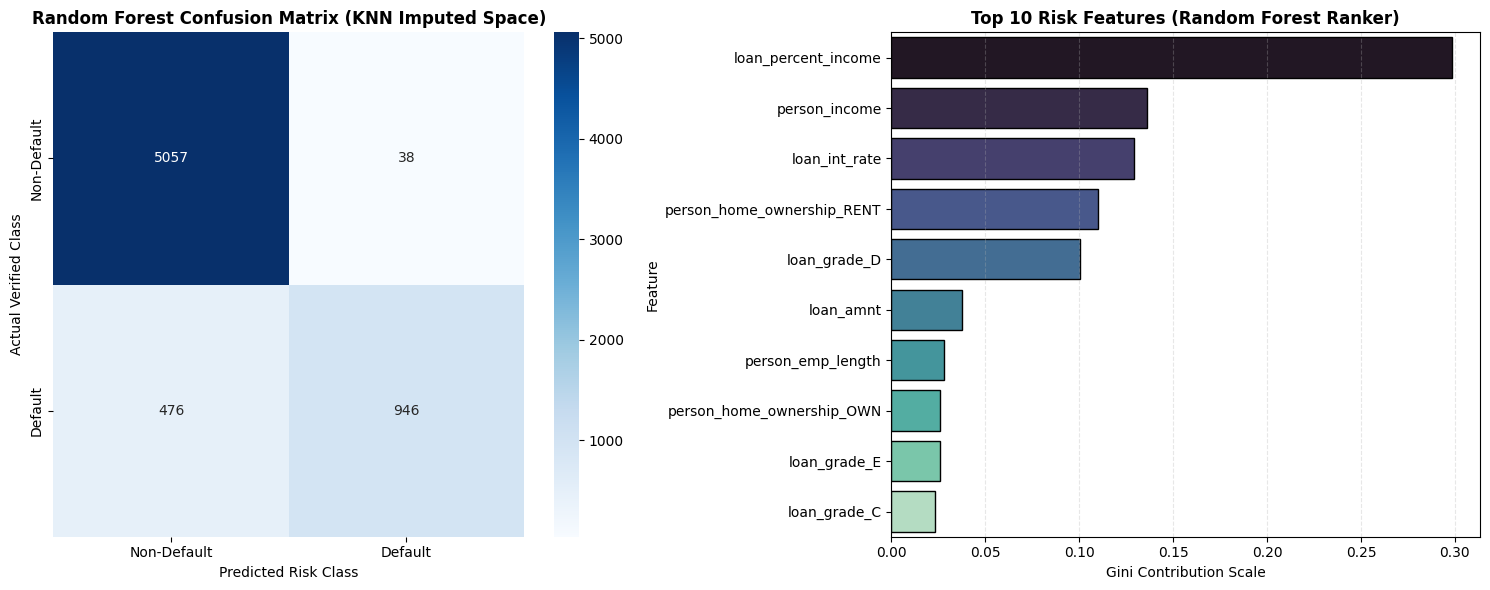

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Confusion Matrix Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Default', 'Default'], yticklabels=['Non-Default', 'Default'], ax=ax[0])
ax[0].set_title('Random Forest Confusion Matrix (KNN Imputed Space)', fontweight='bold', fontsize=12)
ax[0].set_xlabel('Predicted Risk Class')
ax[0].set_ylabel('Actual Verified Class')

# Plot 2: Top 10 Gini Feature Importance Breakdown
feat_imp = pd.DataFrame({'Feature': X_features.columns, 'Importance': rf_cv.feature_importances_}).sort_values(by='Importance', ascending=False)
sns.barplot(data=feat_imp.head(10), x='Importance', y='Feature', palette='mako', hue='Feature', legend=False, edgecolor='black', ax=ax[1])
ax[1].set_title('Top 10 Risk Features (Random Forest Ranker)', fontweight='bold', fontsize=12)
ax[1].set_xlabel('Gini Contribution Scale')
ax[1].grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

### Explanation: Confusion Matrix and Feature Importance Visualization

1.  **Confusion Matrix**: A heatmap of the confusion matrix was generated to visually represent the model's performance. It shows the counts of True Positives, True Negatives, False Positives, and False Negatives. This helps to understand which types of errors the model is making. In our case, it highlights how many defaults were correctly identified (True Positives) and how many non-defaults were wrongly classified as defaults (False Positives).
2.  **Feature Importance**: A bar plot displays the top 10 most important features according to the Random Forest model's Gini importance. Gini importance measures how much a feature contributes to the homogeneity of the nodes and leaves in the decision trees. Features like `loan_percent_income`, `person_income`, and `loan_int_rate` are shown to be highly influential in the model's predictions, aligning with typical financial intuition regarding credit risk.

In [ ]:
# Use the model's predicted probabilities instead of hard 0 or 1 labels
y_pred_proba = rf_cv.predict_proba(X_test)[:, 1]

# Lower the risk tolerance threshold from 0.50 down to 0.35
custom_threshold = 0.35
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

print(f"=== CLASSIFICATION REPORT AT OPTIMIZED RISK THRESHOLD ({custom_threshold}) ===")
print(classification_report(y_test, y_pred_custom))

=== CLASSIFICATION REPORT AT OPTIMIZED RISK THRESHOLD (0.35) ===
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      5095
           1       0.81      0.74      0.77      1422

    accuracy                           0.90      6517
   macro avg       0.87      0.85      0.86      6517
weighted avg       0.90      0.90      0.90      6517



### Explanation: Risk Threshold Optimization

By default, a binary classifier uses a threshold of 0.5 to classify instances into one class or another. However, in credit risk, the cost of a False Negative (failing to identify a defaulter) can be significantly higher than a False Positive (misclassifying a non-defaulter as a defaulter).

This step involves:
1.  **Predicting Probabilities**: Instead of directly predicting 0 or 1, the model's `predict_proba` method was used to get the probability of each instance belonging to the positive class (default).
2.  **Adjusting Threshold**: The classification threshold was lowered from the default 0.5 to 0.35. This means any loan with a predicted probability of default greater than or equal to 0.35 will now be classified as a 'default'. This adjustment is typically made to increase the recall for the positive class, ensuring more potential defaulters are flagged, even if it comes at the cost of a slightly higher number of false positives. The `classification_report` at this new threshold provides insight into the trade-off.

## Key Insights

Based on the analysis, the following key insights can be drawn:

*   **Feature Importance**: `loan_percent_income`, `person_income`, and `loan_int_rate` are the most significant predictors of credit risk. This suggests that the proportion of the loan to income, the borrower's overall income, and the interest rate offered are strong indicators of potential default.
*   **Model Performance**: The Random Forest model demonstrates strong overall accuracy (around 92%) with decent precision and recall for both classes. However, lowering the threshold to 0.35 for the default class (1) significantly improved recall (from 67% to 74%) at a slight trade-off in precision, which is often desirable in credit risk to minimize undetected defaults.
*   **Multicollinearity**: High VIF values for `loan_int_rate` and `person_age` indicate strong relationships with other features. While Random Forest is less affected by multicollinearity than linear models, this information is valuable for understanding the underlying data structure and for potential feature engineering or selection in other model types.
*   **Imputation Effectiveness**: KNN Imputation successfully handled missing values without dropping any rows, preserving the full dataset for analysis, which is crucial for maintaining data integrity and statistical power.

## Recommendations

Based on the insights and model performance, here are some recommendations for financial institutions:

1.  **Focus on Key Risk Indicators**: Prioritize `loan_percent_income`, `person_income`, and `loan_int_rate` when assessing loan applications. These features have the highest predictive power for default.
2.  **Dynamic Thresholding**: Implement a dynamic risk thresholding strategy (e.g., 0.35 as explored) rather than a fixed 0.5. This allows the institution to adjust its risk appetite based on economic conditions or specific business goals, prioritizing recall for defaults to mitigate losses.
3.  **Further Feature Engineering**: Explore creating new features from existing ones, especially around highly correlated variables identified by VIF. For example, `loan_int_rate` combined with credit score or other financial health indicators could yield more robust predictors.
4.  **Explore Other Models**: While Random Forest performs well, consider experimenting with other advanced models like Gradient Boosting Machines (e.g., LightGBM, XGBoost) or neural networks, which might capture more complex non-linear relationships in the data.
5.  **Regular Model Monitoring and Retraining**: Credit risk landscapes change due to economic shifts. The model should be regularly monitored for performance degradation and retrained with fresh data to maintain its accuracy and relevance.
6.  **Cost-Benefit Analysis of Errors**: Conduct a thorough cost-benefit analysis for False Positives (rejecting a good customer) versus False Negatives (approving a defaulting customer). This will help in setting the optimal threshold and fine-tuning the model to align with the institution's financial strategy.